In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import plotly as plty
import yfinance

Data Collection and Feature Engineering 

In [2]:
df = pd.read_csv('data/Inflation_CPI.csv')
df["DATE"] = pd.to_datetime(df["DATE"])
df

,DATE,CPIAUCSL
0,2010-01-01,217.488
1,2010-02-01,217.281
2,2010-03-01,217.353
3,2010-04-01,217.403
4,2010-05-01,217.290
...,...,...
176,2024-09-01,314.732
177,2024-10-01,315.631
178,2024-11-01,316.528
179,2024-12-01,317.604


Inflation means the general increase in prices of goods and services over time. 
If Inflation rises -> The Money buys less

The Consumer Price Index (CPI) is statistical measure used to track inflation.
It measures how the prices of a fixed basket of goods and services changes over time.


In [3]:
df.describe()

,DATE,CPIAUCSL
count,181,181.000000
mean,2017-07-01 13:07:37.458563584,254.490768
min,2010-01-01 00:00:00,217.199000
25%,2013-10-01 00:00:00,233.669000
50%,2017-07-01 00:00:00,244.243000
75%,2021-04-01 00:00:00,266.614000
max,2025-01-01 00:00:00,318.961000
std,NaN,28.786628


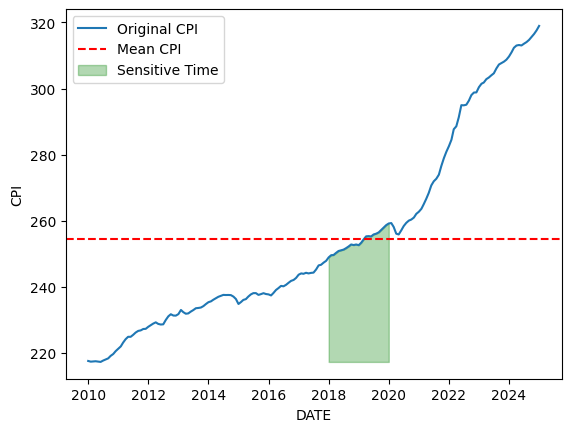

In [4]:
x = df["CPIAUCSL"].values
y = df["DATE"].values

x_mean = df["CPIAUCSL"].values.mean()
x_std = df["CPIAUCSL"].values.std()

mask = (df['DATE'] >= "2018-01-01") & (df["DATE"] <= "2020-01-01")

y_min = min(x)

plt.plot(y,x,label = "Original CPI")
plt.axhline(x_mean, color= 'r', linestyle = '--', label = "Mean CPI")
# plt.plot(y_n,x_n, color = 'g', alpha = 0.5, linestyle = "-", label = "Sensitive Area")
plt.fill_between(
    y,x,
    y_min,
    where = mask,
    color = 'green',
    alpha = 0.3,
    label = "Sensitive Time"
)
plt.xlabel("DATE")
plt.legend()
plt.ylabel("CPI")
plt.show()

In [5]:
df1 = pd.read_csv("data/APPLE.csv")
df1

,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,6.412384510040283,6.427066322741706,6.363544880017381,6.395005964384629,493729600
3,2010-01-05,6.423468589782715,6.459723852019821,6.389610022526822,6.430060601116457,601904800
4,2010-01-06,6.321296215057373,6.44893875336688,6.314704202262994,6.423470013074288,552160000
...,...,...,...,...,...,...
3771,2024-12-24,256.7972106933594,256.80713572411884,253.90300191480816,254.10192745486222,23234700
3772,2024-12-26,257.6127014160156,258.6868506395932,256.2302692406472,256.7872242633273,27237100
3773,2024-12-27,254.2013702392578,257.29448932345014,251.68511699924173,256.42919055718573,42355300
3774,2024-12-30,250.82980346679688,252.122743648892,249.38768429964367,250.8596392638085,35557500


In [6]:
df1.describe()

,Price,Close,High,Low,Open,Volume
count,3776,3775,3775,3775,3775,3775
unique,3776,3723,3775,3775,3775,3766
top,2024-12-06,26.274696350097656,251.90392569582917,248.07483671879714,251.0684930674946,391638800
freq,1,2,1,1,1,2


In [7]:
df1.rename(columns={'Price': 'Date'}, inplace = True)
df1.isnull().sum()
# df1.remove(None)
df1 =df1.dropna()
df1 = df1.drop_duplicates()
df1.reset_index(inplace = True, drop = True)
df1['Date'] = pd.to_datetime(df1['Date'],errors = 'coerce')

df1 = df1.dropna(subset=['Date'])

df1




C:\Users\Tanmay\AppData\Local\Temp\ipykernel_17208\2302291601.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Date'] = pd.to_datetime(df1['Date'],errors = 'coerce')


,Date,Close,High,Low,Open,Volume
1,2010-01-04,6.412384510040283,6.427066322741706,6.363544880017381,6.395005964384629,493729600
2,2010-01-05,6.423468589782715,6.459723852019821,6.389610022526822,6.430060601116457,601904800
3,2010-01-06,6.321296215057373,6.44893875336688,6.314704202262994,6.423470013074288,552160000
4,2010-01-07,6.3096113204956055,6.352159375743484,6.263768058246057,6.344668450515088,477131200
5,2010-01-08,6.35155725479126,6.352156928627924,6.26406608217472,6.301219456796891,447610800
...,...,...,...,...,...,...
3770,2024-12-24,256.7972106933594,256.80713572411884,253.90300191480816,254.10192745486222,23234700
3771,2024-12-26,257.6127014160156,258.6868506395932,256.2302692406472,256.7872242633273,27237100
3772,2024-12-27,254.2013702392578,257.29448932345014,251.68511699924173,256.42919055718573,42355300
3773,2024-12-30,250.82980346679688,252.122743648892,249.38768429964367,250.8596392638085,35557500


In [8]:
df1.set_index

<bound method DataFrame.set_index of            Date               Close                High                 Low  \
1    2010-01-04   6.412384510040283   6.427066322741706   6.363544880017381   
2    2010-01-05   6.423468589782715   6.459723852019821   6.389610022526822   
3    2010-01-06   6.321296215057373    6.44893875336688   6.314704202262994   
4    2010-01-07  6.3096113204956055   6.352159375743484   6.263768058246057   
5    2010-01-08    6.35155725479126   6.352156928627924    6.26406608217472   
...         ...                 ...                 ...                 ...   
3770 2024-12-24   256.7972106933594  256.80713572411884  253.90300191480816   
3771 2024-12-26   257.6127014160156   258.6868506395932   256.2302692406472   
3772 2024-12-27   254.2013702392578  257.29448932345014  251.68511699924173   
3773 2024-12-30  250.82980346679688    252.122743648892  249.38768429964367   
3774 2024-12-31  249.05946350097656  251.90392569582917  248.07483671879714   

              

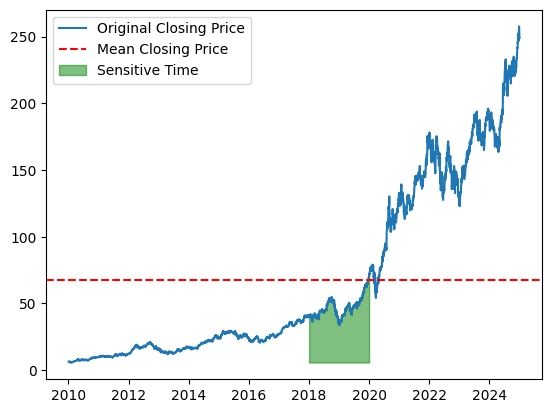

In [13]:
df1['Close'] = pd.to_numeric(df1['Close'], errors = 'coerce')
df1['Close'] = df1['Close'].round(2)

mask_cls = ((df1['Date'] >= "2018-01-01" ) & (df1['Date'] <= "2020-01-01"))
x_close = df1['Close'].values
y_close = df1['Date'].values
x_close_mean = df1['Close'].values.mean()

y_min_close = min(x_close)


plt.plot(y_close,x_close, label = "Original Closing Price")
plt.axhline(x_close_mean, color = 'r', linestyle = '--', label = "Mean Closing Price")
plt.fill_between(
    y_close, x_close,
    y_min_close,
    where =mask_cls,
    color = 'g',
    alpha = 0.5,
    label = 'Sensitive Time'
)
plt.legend()
plt.show()